In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load all CSV files
telemetry = pd.read_csv('PdM_telemetry.csv')
errors = pd.read_csv('PdM_errors.csv') 
failures = pd.read_csv('PdM_failures.csv')
maintenance = pd.read_csv('PdM_maint.csv')
machines = pd.read_csv('PdM_machines.csv')

print(f"Telemetry shape: {telemetry.shape}")
print(f"Failures shape: {failures.shape}")

Telemetry shape: (876100, 6)
Failures shape: (761, 3)


In [4]:
print(f"Available components: {failures['failure'].unique()}")

Available components: ['comp4' 'comp1' 'comp2' 'comp3']


In [5]:
# Convert datetime columns
telemetry['datetime'] = pd.to_datetime(telemetry['datetime'])
failures['datetime'] = pd.to_datetime(failures['datetime'])

# Create component failure labels for each machine-hour
# Instead of binary (0/1), we now have component types (comp1, comp2, comp3, comp4)
telemetry_with_labels = telemetry.copy()
telemetry_with_labels['component_failure'] = 'none'  # Default: no failure

# For each component failure, mark previous 24 hours with that component type
prediction_window_hours = 24

for idx, failure_row in failures.iterrows():
    machine_id = failure_row['machineID']
    failure_time = failure_row['datetime']
    component_type = failure_row['failure']  # e.g., 'comp1', 'comp2', etc.
    
    # Find telemetry records 24 hours before this component failure
    start_time = failure_time - pd.Timedelta(hours=prediction_window_hours)
    
    # Mark these records with the specific component that will fail
    mask = ((telemetry_with_labels['machineID'] == machine_id) & 
            (telemetry_with_labels['datetime'] >= start_time) & 
            (telemetry_with_labels['datetime'] < failure_time) &
            (telemetry_with_labels['component_failure'] == 'none'))  # Don't overwrite existing labels
    
    telemetry_with_labels.loc[mask, 'component_failure'] = component_type

In [6]:
component_counts = telemetry_with_labels['component_failure'].value_counts()
print(f"\nComponent failure distribution:")
for component, count in component_counts.items():
    percentage = count / len(telemetry_with_labels) * 100
    print(f"{component}: {count:,} samples ({percentage:.2f}%)")


Component failure distribution:
none: 858,916 samples (98.04%)
comp2: 5,991 samples (0.68%)
comp1: 4,581 samples (0.52%)
comp4: 3,711 samples (0.42%)
comp3: 2,901 samples (0.33%)


In [7]:
# Sort by machine and time for rolling calculations
telemetry_with_labels = telemetry_with_labels.sort_values(['machineID', 'datetime'])

# Create rolling window features (last 6 hours averages and trends)
window_size = 6
feature_data = []

for machine_id in telemetry_with_labels['machineID'].unique():
    machine_data = telemetry_with_labels[telemetry_with_labels['machineID'] == machine_id].copy()
    
    # Rolling averages for each sensor
    machine_data['volt_avg_6h'] = machine_data['volt'].rolling(window_size).mean()
    machine_data['rotate_avg_6h'] = machine_data['rotate'].rolling(window_size).mean()
    machine_data['pressure_avg_6h'] = machine_data['pressure'].rolling(window_size).mean()
    machine_data['vibration_avg_6h'] = machine_data['vibration'].rolling(window_size).mean()
    
    # Rolling standard deviations (measure variability/instability)
    machine_data['volt_std_6h'] = machine_data['volt'].rolling(window_size).std()
    machine_data['rotate_std_6h'] = machine_data['rotate'].rolling(window_size).std()
    machine_data['pressure_std_6h'] = machine_data['pressure'].rolling(window_size).std()
    machine_data['vibration_std_6h'] = machine_data['vibration'].rolling(window_size).std()
    
    # Trends (current value - average) - indicates if sensor is increasing/decreasing
    machine_data['volt_trend'] = machine_data['volt'] - machine_data['volt_avg_6h']
    machine_data['rotate_trend'] = machine_data['rotate'] - machine_data['rotate_avg_6h']
    machine_data['pressure_trend'] = machine_data['pressure'] - machine_data['pressure_avg_6h']
    machine_data['vibration_trend'] = machine_data['vibration'] - machine_data['vibration_avg_6h']
    
    # Component-specific features (ratios that might indicate specific component issues)
    machine_data['pressure_vibration_ratio'] = machine_data['pressure'] / (machine_data['vibration'] + 1)
    machine_data['volt_rotate_ratio'] = machine_data['volt'] / (machine_data['rotate'] + 1)
    
    feature_data.append(machine_data)

# Combine all machines
full_data = pd.concat(feature_data, ignore_index=True)


In [8]:
# Add error count features
error_counts = errors.groupby(['machineID', 'datetime']).size().reset_index(name='error_count')
error_counts['datetime'] = pd.to_datetime(error_counts['datetime'])

# Merge error counts
full_data = full_data.merge(error_counts, on=['machineID', 'datetime'], how='left')
full_data['error_count'] = full_data['error_count'].fillna(0)

# Add machine features (age, model)
full_data = full_data.merge(machines, on='machineID', how='left')

print(f"Feature engineering complete. Shape: {full_data.shape}")

Feature engineering complete. Shape: (876100, 24)


In [9]:
# Remove rows with NaN (from rolling window calculations)
full_data = full_data.dropna()

# Select features for training
feature_columns = [
    'volt', 'rotate', 'pressure', 'vibration',  # Current sensor readings
    'volt_avg_6h', 'rotate_avg_6h', 'pressure_avg_6h', 'vibration_avg_6h',  # Rolling averages
    'volt_std_6h', 'rotate_std_6h', 'pressure_std_6h', 'vibration_std_6h',  # Variability measures
    'volt_trend', 'rotate_trend', 'pressure_trend', 'vibration_trend',  # Trend indicators
    'pressure_vibration_ratio', 'volt_rotate_ratio',  # Component-specific ratios
    'error_count',  # Error information
    'age', 'model'  # Machine characteristics
]

# Handle categorical variables (model type)
full_data['model'] = full_data['model'].astype('category').cat.codes


In [10]:
# Encode component labels to numbers
label_encoder = LabelEncoder()
full_data['component_encoded'] = label_encoder.fit_transform(full_data['component_failure'])

# Save label encoder for later use
joblib.dump(label_encoder, 'component_label_encoder.pkl')

# Prepare X (features) and y (target)
X = full_data[feature_columns]
y = full_data['component_encoded']

print(f"Training data shape: X={X.shape}, y={y.shape}")
print(f"Component classes: {label_encoder.classes_}")
print(f"Class distribution: {np.bincount(y)}")


Training data shape: X=(875600, 21), y=(875600,)
Component classes: ['comp1' 'comp2' 'comp3' 'comp4' 'none']
Class distribution: [  4526   5976   2891   3696 858511]


In [11]:
# Stratified split to maintain component distribution in train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Check class distribution in splits
print(f"Train class distribution: {np.bincount(y_train)}")
print(f"Test class distribution: {np.bincount(y_test)}")

Training set: (700480, 21)
Test set: (175120, 21)
Train class distribution: [  3620   4781   2313   2957 686809]
Test class distribution: [   906   1195    578    739 171702]


In [12]:
# Create Random Forest for multi-class classification
model = RandomForestClassifier(
    n_estimators=100,           # Number of trees
    max_depth=15,               # Maximum depth (slightly deeper for multi-class)
    min_samples_split=5,        # Minimum samples to split a node
    min_samples_leaf=2,         # Minimum samples in leaf node
    class_weight='balanced',    # Handle class imbalance automatically
    random_state=42,
    n_jobs=-1                   # Use all CPU cores
)

# Train the model
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=2, min_samples_split=5, n_jobs=-1,
                       random_state=42)

In [13]:
# Predict on test set
y_pred_proba = model.predict_proba(X_test)  # Probabilities for each component
y_pred = model.predict(X_test)  # Predicted component class


In [14]:
# Calculate overall accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.4f} ({accuracy:.1%})")


Overall Accuracy: 0.8978 (89.8%)


In [15]:
# Print classification report (precision, recall, f1-score for each component)
print("\nMulti-class Classification Report:")
target_names = label_encoder.classes_
print(classification_report(y_test, y_pred, target_names=target_names))


Multi-class Classification Report:
              precision    recall  f1-score   support

       comp1       0.10      0.80      0.18       906
       comp2       0.14      0.88      0.25      1195
       comp3       0.22      0.94      0.35       578
       comp4       0.19      0.90      0.32       739
        none       1.00      0.90      0.95    171702

    accuracy                           0.90    175120
   macro avg       0.33      0.88      0.41    175120
weighted avg       0.98      0.90      0.93    175120



In [16]:
# Print confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)


Confusion Matrix:
[[   722     11     11      4    158]
 [    10   1048      4      6    127]
 [     0      7    542      3     26]
 [     0     13      3    668     55]
 [  6536   6201   1946   2770 154249]]


In [18]:
# Feature importance for multi-class
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features for Component Prediction:")
print(feature_importance.head(10))



Top 10 Most Important Features for Component Prediction:
                     feature  importance
4                volt_avg_6h    0.172755
5              rotate_avg_6h    0.166747
7           vibration_avg_6h    0.160771
6            pressure_avg_6h    0.159095
2                   pressure    0.053815
1                     rotate    0.037474
3                  vibration    0.036652
20                     model    0.033056
0                       volt    0.030018
16  pressure_vibration_ratio    0.024437


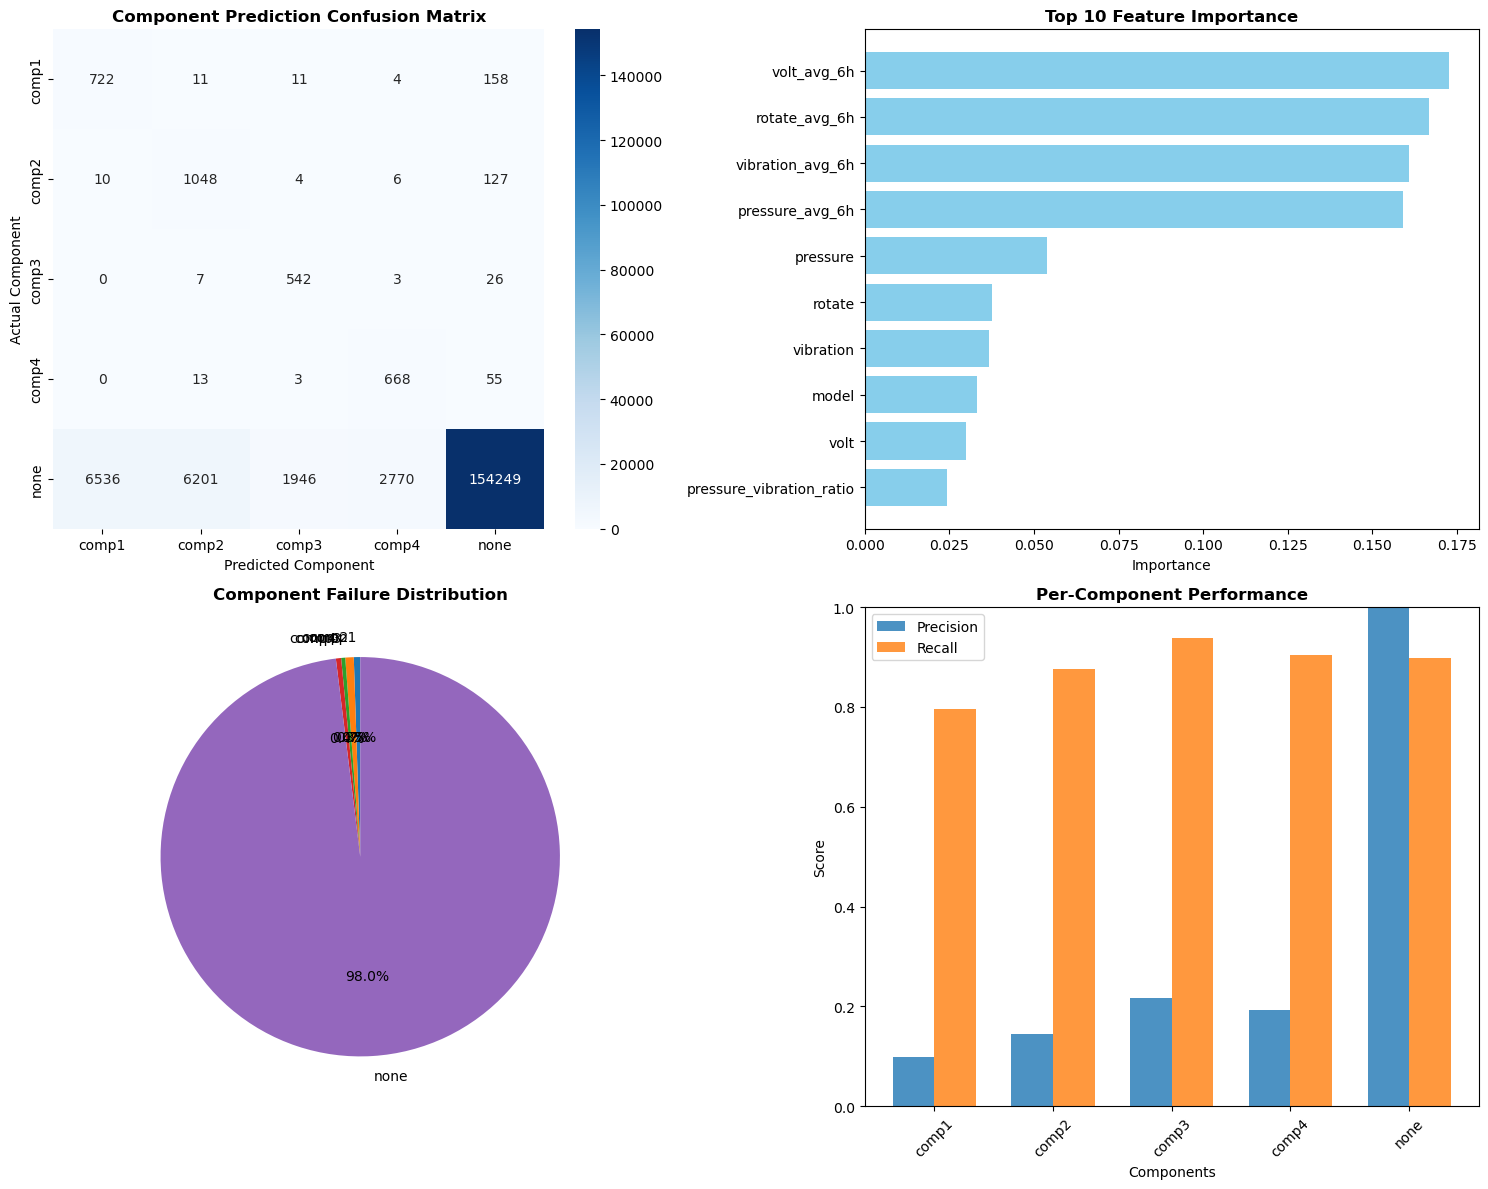

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

ax1 = axes[0, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names, ax=ax1)
ax1.set_title('Component Prediction Confusion Matrix', fontweight='bold')
ax1.set_ylabel('Actual Component')
ax1.set_xlabel('Predicted Component')
# 2. Feature Importance
ax2 = axes[0, 1]
top_features = feature_importance.head(10)
ax2.barh(range(len(top_features)), top_features['importance'], color='skyblue')
ax2.set_yticks(range(len(top_features)))
ax2.set_yticklabels(top_features['feature'])
ax2.set_xlabel('Importance')
ax2.set_title('Top 10 Feature Importance', fontweight='bold')
ax2.invert_yaxis()

# 3. Class Distribution
ax3 = axes[1, 0]
class_counts = pd.Series(y).value_counts().sort_index()
component_names = [label_encoder.classes_[i] for i in class_counts.index]
ax3.pie(class_counts.values, labels=component_names, autopct='%1.1f%%', startangle=90)
ax3.set_title('Component Failure Distribution', fontweight='bold')

# 4. Per-component Performance
ax4 = axes[1, 1]
report_dict = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)
components = target_names
precision_scores = [report_dict[comp]['precision'] for comp in components]
recall_scores = [report_dict[comp]['recall'] for comp in components]
x = np.arange(len(components))
width = 0.35

ax4.bar(x - width/2, precision_scores, width, label='Precision', alpha=0.8)
ax4.bar(x + width/2, recall_scores, width, label='Recall', alpha=0.8)
ax4.set_xlabel('Components')
ax4.set_ylabel('Score')
ax4.set_title('Per-Component Performance', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(components, rotation=45)
ax4.legend()
ax4.set_ylim(0, 1)

plt.tight_layout()
plt.show()


In [20]:
def predict_component_failure(machine_id, target_datetime):
    """
    Predict which component will fail in the next 24 hours
    
    Parameters:
    - machine_id: ID of the machine to check
    - target_datetime: datetime to make prediction from (format: 'YYYY-MM-DD HH:MM:SS')
    
    Returns:
    - Dictionary with component prediction results
    """
    
    # Convert input datetime
    target_time = pd.to_datetime(target_datetime)
    
    # Check if machine exists
    if machine_id not in full_data['machineID'].unique():
        return {"error": f"Machine ID {machine_id} not found in dataset"}
    
    # Get machine data up to target datetime
    machine_history = full_data[
        (full_data['machineID'] == machine_id) & 
        (full_data['datetime'] <= target_time)
    ].sort_values('datetime')
    
    if len(machine_history) == 0:
        return {"error": f"No data found for Machine {machine_id} at {target_datetime}"}
    
    # Get the latest available record
    latest_record = machine_history.iloc[-1]
    
    # Prepare features for prediction
    prediction_features = []
    for col in feature_columns:
        if col in latest_record:
            prediction_features.append(latest_record[col])
        else:
            prediction_features.append(0)  # Default value if missing
    
    # Reshape for prediction
    features_array = np.array(prediction_features).reshape(1, -1)
    
    # Make predictions
    component_probabilities = model.predict_proba(features_array)[0]
    predicted_component_idx = model.predict(features_array)[0]
    predicted_component = label_encoder.inverse_transform([predicted_component_idx])[0]
    
    # Get current sensor readings
    current_sensors = {
        'voltage': latest_record['volt'],
        'rotation': latest_record['rotate'], 
        'pressure': latest_record['pressure'],
        'vibration': latest_record['vibration']
    }
    
    # Create component probability dictionary
    component_probs = {}
    for i, prob in enumerate(component_probabilities):
        component_name = label_encoder.inverse_transform([i])[0]
        component_probs[component_name] = round(prob, 3)
    
    # Determine risk level based on highest probability
    max_prob = max(component_probabilities)
    risk_level = "HIGH" if max_prob > 0.7 else "MEDIUM" if max_prob > 0.4 else "LOW"
    
    # Return results
    result = {
        "machine_id": machine_id,
        "prediction_time": target_datetime,
        "data_time": latest_record['datetime'].strftime('%Y-%m-%d %H:%M:%S'),
        "predicted_component": predicted_component,
        "component_probabilities": component_probs,
        "max_probability": round(max_prob, 3),
        "risk_level": risk_level,
        "current_sensors": current_sensors,
        "recommendation": f"Schedule {predicted_component} maintenance" if max_prob > 0.5 else "Continue monitoring all components",
        "model_type": "Random Forest Multi-class"
    }
    
    return result


In [21]:
test_cases = [
    {"machine_id": 1, "datetime": "2015-03-05 06:00:00"},
    {"machine_id": 5, "datetime": "2015-08-20 08:00:00"}, 
    {"machine_id": 10, "datetime": "2015-10-01 14:00:00"},
    {"machine_id": 25, "datetime": "2015-12-15 10:00:00"}
]
for i, test_case in enumerate(test_cases, 1):
    print(f"\n--- TEST CASE {i} ---")
    result = predict_component_failure(test_case["machine_id"], test_case["datetime"])
    
    if "error" in result:
        print(f"❌ {result['error']}")
    else:
        print(f"🏭 Machine ID: {result['machine_id']}")
        print(f"📅 Prediction Time: {result['prediction_time']}")
        print(f"🎯 Predicted Component to fail: {result['predicted_component'].upper()}")
        print(f"📈 Confidence: {result['max_probability']:.1%}")
        #print(f"🚨 Risk Level: {result['risk_level']}")
        print(f"💡 Recommendation: {result['recommendation']}")
        print(f"📊 Component Probabilities:")
        for component, prob in result['component_probabilities'].items():
            emoji = "⚠️" if prob == result['max_probability'] else "  "
            print(f"   {emoji} {component}: {prob:.1%}")


--- TEST CASE 1 ---


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


🏭 Machine ID: 1
📅 Prediction Time: 2015-03-05 06:00:00
🎯 Predicted Component to fail: COMP1
📈 Confidence: 84.9%
💡 Recommendation: Schedule comp1 maintenance
📊 Component Probabilities:
   ⚠️ comp1: 84.9%
      comp2: 0.1%
      comp3: 0.0%
      comp4: 0.2%
      none: 14.9%

--- TEST CASE 2 ---


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


🏭 Machine ID: 5
📅 Prediction Time: 2015-08-20 08:00:00
🎯 Predicted Component to fail: NONE
📈 Confidence: 97.7%
💡 Recommendation: Schedule none maintenance
📊 Component Probabilities:
      comp1: 1.3%
      comp2: 0.8%
      comp3: 0.0%
      comp4: 0.1%
   ⚠️ none: 97.7%

--- TEST CASE 3 ---


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


🏭 Machine ID: 10
📅 Prediction Time: 2015-10-01 14:00:00
🎯 Predicted Component to fail: NONE
📈 Confidence: 97.7%
💡 Recommendation: Schedule none maintenance
📊 Component Probabilities:
      comp1: 1.1%
      comp2: 1.0%
      comp3: 0.0%
      comp4: 0.1%
   ⚠️ none: 97.7%

--- TEST CASE 4 ---


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


🏭 Machine ID: 25
📅 Prediction Time: 2015-12-15 10:00:00
🎯 Predicted Component to fail: NONE
📈 Confidence: 94.8%
💡 Recommendation: Schedule none maintenance
📊 Component Probabilities:
      comp1: 3.3%
      comp2: 1.8%
      comp3: 0.0%
      comp4: 0.1%
   ⚠️ none: 94.8%


In [22]:
def interactive_component_prediction():
    """Interactive function to test component predictions with custom inputs"""
    
    print("\nEnter machine details for component failure prediction:")
    print("Available Machine IDs: 1-100")
    print("Date format: YYYY-MM-DD HH:MM:SS (e.g., 2015-06-15 12:00:00)")
    
    try:
        # Get user input
        machine_id = int(input("\nEnter Machine ID (1-100): "))
        datetime_str = input("Enter datetime (YYYY-MM-DD HH:MM:SS): ")
        
        # Make prediction
        result = predict_component_failure(machine_id, datetime_str)
        
        print("\n" + "-"*60)
        print("🔧 COMPONENT FAILURE PREDICTION RESULT")
        print("-"*60)
        
        if "error" in result:
            print(f"❌ Error: {result['error']}")
        else:
            print(f"Machine {result['machine_id']} Component Analysis:")
            print(f"🎯 Most Likely to Fail: {result['predicted_component'].upper()}")
            print(f"📈 Probability: {result['max_probability']:.1%}")
            #print(f"🚨 Risk Level: {result['risk_level']}")
            print(f"💡 Action: {result['recommendation']}")
            
            print(f"\n📊 All Component Probabilities:")
            sorted_probs = sorted(result['component_probabilities'].items(), 
                                key=lambda x: x[1], reverse=True)
            for component, prob in sorted_probs:
                status = "⚠️" if prob > 0.5 else "⚠️ MONITOR" if prob > 0.2 else "✅"
                print(f"   {component}: {prob:.1%} {status}")
    
    except KeyboardInterrupt:
        print("\nPrediction cancelled.")
    except Exception as e:
        print(f"Error: {e}")


In [23]:
interactive_component_prediction()


Enter machine details for component failure prediction:
Available Machine IDs: 1-100
Date format: YYYY-MM-DD HH:MM:SS (e.g., 2015-06-15 12:00:00)



Enter Machine ID (1-100):  55
Enter datetime (YYYY-MM-DD HH:MM:SS):  2015-06-15 09:00:00


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



------------------------------------------------------------
🔧 COMPONENT FAILURE PREDICTION RESULT
------------------------------------------------------------
Machine 55 Component Analysis:
🎯 Most Likely to Fail: NONE
📈 Probability: 95.8%
💡 Action: Schedule none maintenance

📊 All Component Probabilities:
   none: 95.8% ⚠️
   comp2: 2.4% ✅
   comp1: 1.5% ✅
   comp4: 0.3% ✅
   comp3: 0.1% ✅


In [24]:
interactive_component_prediction()


Enter machine details for component failure prediction:
Available Machine IDs: 1-100
Date format: YYYY-MM-DD HH:MM:SS (e.g., 2015-06-15 12:00:00)



Enter Machine ID (1-100):  2
Enter datetime (YYYY-MM-DD HH:MM:SS):  2015-04-18 07:00:00


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



------------------------------------------------------------
🔧 COMPONENT FAILURE PREDICTION RESULT
------------------------------------------------------------
Machine 2 Component Analysis:
🎯 Most Likely to Fail: NONE
📈 Probability: 84.6%
💡 Action: Schedule none maintenance

📊 All Component Probabilities:
   none: 84.6% ⚠️
   comp2: 11.5% ✅
   comp4: 4.0% ✅
   comp1: 0.0% ✅
   comp3: 0.0% ✅


In [25]:
interactive_component_prediction()


Enter machine details for component failure prediction:
Available Machine IDs: 1-100
Date format: YYYY-MM-DD HH:MM:SS (e.g., 2015-06-15 12:00:00)



Enter Machine ID (1-100):  2
Enter datetime (YYYY-MM-DD HH:MM:SS):  2015-04-17 07:00:00



------------------------------------------------------------
🔧 COMPONENT FAILURE PREDICTION RESULT
------------------------------------------------------------
Machine 2 Component Analysis:
🎯 Most Likely to Fail: COMP2
📈 Probability: 89.4%
💡 Action: Schedule comp2 maintenance

📊 All Component Probabilities:
   comp2: 89.4% ⚠️
   none: 8.3% ✅
   comp4: 2.3% ✅
   comp1: 0.0% ✅
   comp3: 0.0% ✅


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
